In [9]:
from collections.abc import Iterable
from idlelib import history
from typing import override

import dnnlpy
import dnnlpy.optim as dopt
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

dnnlpy.set_matplotlib_format('svg')
print("PyTorch version: ", torch.__version__)

PyTorch version:  2.13.0+cpu


Final  theta: tensor([ 1.7508, -1.0000])
Final  loss: 0.0062118638306856155


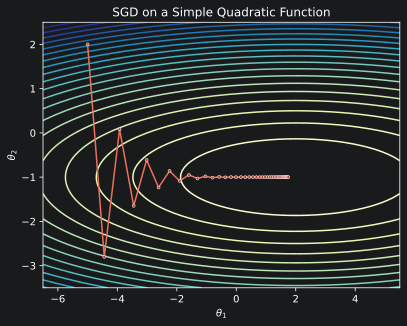

In [10]:
"""
用一个简单的例子来观察梯度下降
"""


def loss_fn(theta: Tensor) -> Tensor:
    x, y = theta[0], theta[1]
    return 0.1 * (x - 2) ** 2 + 2 * (y + 1) ** 2


# 实现一个简单的梯度下降
class SimpleSGD(dopt.Optimizer):
    def __init__(self, params: Iterable[Tensor], lr: float = 1e-3):
        super().__init__(params)
        self.lr = lr

    @override
    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            p.sub_(p.grad, alpha=self.lr)


# 运行梯度下降,并观察其轨迹
theta = torch.tensor([-5.0, 2.0], requires_grad=True)
optimizer = SimpleSGD([theta], lr=0.4)
history = dopt.run_optimizer(optimizer, loss_fn, steps=40)

print("Final  theta:", history[-1])
print("Final  loss:", loss_fn(history[-1]).item())

# 绘制梯度轨迹
x = torch.linspace(-6.5, 5.5, 200)
y = torch.linspace(-3.5, 2.5, 200)
X, Y = torch.meshgrid(x, y, indexing='ij')
Z = 0.1 * (X - 2) ** 2 + 2 * (Y + 1) ** 2

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.contour(X, Y, Z, levels=25, cmap='YlGnBu')
ax.plot(
    history[:, 0],
    history[:, 1],
    color='#EC705B',
    marker='o',
    markersize=3,
    markerfacecolor='#C0392B',
    markeredgecolor='white',
    markeredgewidth=0.5,
)

ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_title('SGD on a Simple Quadratic Function')
plt.show()

In [11]:
"""
Mini -batch SGD:深度学习的默认的训练方式
"""
model = nn.Linear(1, 1)
optimizer = optim.SGD(model.parameters(), lr=0.1)

x = torch.randn(32, 1)
y = 2 * x + 1

pred = model(x)
loss = F.mse_loss(pred, y)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Mini-batch loss:", loss.item())

Mini-batch loss: 6.291378021240234


In [14]:
"""
SGD的Weight Decay
    这里的weight_decay 不是直接从参数中减去一个固定值,而是按照参数的比例的衰减
"""


class SimpleSGDWithWeightDecay(dopt.Optimizer):
    def __init__(self, params: Iterable[Tensor], lr: float = 1e-3, weight_decay: float = 0.0):
        super().__init__(params)
        self.lr = lr
        self.weight_decay = weight_decay

    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            grad = p.grad
            if self.weight_decay > 0:
                grad = grad.add(p, alpha=self.weight_decay)
            p.sub(grad, alpha=self.lr)


# 检验效果
thetal1 = torch.tensor([-5.0, 2.0], requires_grad=True)
thetal2 = torch.tensor([-5.0, 2.0], requires_grad=True)
optimizer1 = SimpleSGD([thetal1], lr=0.4)
optimizer2 = SimpleSGDWithWeightDecay([thetal2], lr=0.4, weight_decay=0.2)
history_no_decay = dopt.run_optimizer(optimizer1, loss_fn, steps=40)
history_with_decay = dopt.run_optimizer(optimizer2, loss_fn, steps=40)

print("Without weight decay:")
print("Final theta:",history_no_decay[-1])
print('Final loss:', loss_fn(history_no_decay[-1]).item())

print("With weight decay:")
print("Final theta:",history_with_decay[-1])
print("Final loss:", loss_fn(history_with_decay[-1]).item())


Without weight decay:
Final theta: tensor([ 1.7508, -1.0000])
Final loss: 0.0062118638306856155
With weight decay:
Final theta: tensor([-5.,  2.])
Final loss: 22.899999618530273
